# Power Analysis for Large Dataset Sample Size Planning

This notebook performs statistical power analysis to determine the minimum sample size needed to detect effects of macro-axes on rating outcomes in a larger dataset.

**Outcomes**: `rating_mean`, `avg_rating_bayes`  
**Predictors**: 6 macro-axes (AX_status_dominance, AX_payoff_safety, AX_negative_affect, AX_explicitness, AX_attraction, AX_drama_obstacle)  
**Control**: `log_rating_count`  
**Models**: OLS (no author FE) and Author Fixed Effects (within-author demeaning)

## Important Technical Note

**Z-scoring approach**: Variables are z-scored **once globally** before the bootstrap simulation, NOT within each replicate. This preserves the population-scale structure and collinearity patterns, preventing inflated power estimates. Re-standardizing within each replicate would remove scale differences and collinearity structure, giving each axis an "equalized playing field" that doesn't reflect real-world estimation conditions.

In [16]:
# ============================================================
# CELL 1 — Setup & Path Resolution
# ============================================================
from __future__ import annotations

from pathlib import Path
import os
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def normalize_id(x) -> str:
    """Normalize book IDs (remove .0 suffix if present)."""
    s = str(x).strip()
    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]
    return s

# Find project root by walking up until we find both 'results' and 'data' directories
def find_project_root(start: Path) -> Path:
    """Walk up directory tree to find project root (contains both 'results' and 'data' directories)."""
    current = start.resolve()
    while current != current.parent:
        results_dir = current / "results"
        data_dir = current / "data"
        if results_dir.exists() and results_dir.is_dir() and data_dir.exists() and data_dir.is_dir():
            return current
        current = current.parent
    # Fallback: use environment variable
    env_root = os.environ.get("ROMANCE_ROOT", "")
    if env_root:
        return Path(env_root).expanduser().resolve()
    return Path.cwd().resolve()

# Try multiple strategies to find project root
PROJECT_ROOT = None

# Strategy 1: Use environment variable
env_root = os.environ.get("ROMANCE_ROOT", "")
if env_root and Path(env_root).expanduser().exists():
    PROJECT_ROOT = Path(env_root).expanduser().resolve()

# Strategy 2: Walk up from current working directory
if PROJECT_ROOT is None or not (PROJECT_ROOT / "results").exists():
    candidate = find_project_root(Path.cwd())
    if (candidate / "results").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate

# Final fallback: use known absolute path
if PROJECT_ROOT is None or not (PROJECT_ROOT / "results").exists():
    known_path = Path("/home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor")
    if known_path.exists() and (known_path / "results").exists() and (known_path / "data").exists():
        PROJECT_ROOT = known_path

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not determine PROJECT_ROOT. Please set ROMANCE_ROOT environment variable.")

PROJECT_ROOT = PROJECT_ROOT.resolve()
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR = PROJECT_ROOT / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("DATA_DIR:", DATA_DIR)

PROJECT_ROOT: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor
RESULTS_DIR: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results
DATA_DIR: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/data


In [17]:
# ============================================================
# CELL 2 — Load book-level data
# ============================================================
# Try parquet first, then CSV
BOOK_INDICES_PARQUET = RESULTS_DIR / "stage10_correlation_analysis" / "03_composite_measurement" / "book_indices_z.parquet"
BOOK_INDICES_CSV = RESULTS_DIR / "stage10_correlation_analysis" / "03_composite_measurement" / "audit" / "book_indices_z.csv"

if BOOK_INDICES_PARQUET.exists():
    df_books = pd.read_parquet(BOOK_INDICES_PARQUET)
    print(f"Loaded book indices from parquet: {BOOK_INDICES_PARQUET}")
elif BOOK_INDICES_CSV.exists():
    df_books = pd.read_csv(BOOK_INDICES_CSV)
    print(f"Loaded book indices from CSV: {BOOK_INDICES_CSV}")
else:
    raise FileNotFoundError(f"Book indices not found. Tried:\n  {BOOK_INDICES_PARQUET}\n  {BOOK_INDICES_CSV}")

# Normalize book_id
df_books["book_id"] = df_books["book_id"].map(normalize_id)

print("\nLoaded df_books")
print("Rows:", len(df_books))
print("Columns:", len(df_books.columns))
print("Sample columns:", df_books.columns.tolist()[:20], "...")
print("All columns (40):", df_books.columns.tolist()[:40])

Loaded book indices from parquet: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage10_correlation_analysis/03_composite_measurement/book_indices_z.parquet

Loaded df_books
Rows: 92
Columns: 40
Sample columns: ['book_id', 'A1_commitment_vows', 'A2_emotional_safety', 'A3_everyday_tenderness', 'B1_attraction_chemistry', 'B2_emotional_intimacy', 'C_explicit_eroticism', 'D_power_wealth_luxury', 'E_coercion_brutality_danger', 'F1_sadness_grief', 'F2_anger_frustration', 'F3_anxiety_worry', 'G_courtship_rituals_gifts', 'L_vices_addictions', 'M_health_recovery_growth', 'H_domestic_nesting', 'I_humor_lightness', 'J_social_support_kin', 'K_professional_intrusion', 'N_separation_reunion'] ...
All columns (40): ['book_id', 'A1_commitment_vows', 'A2_emotional_safety', 'A3_everyday_tenderness', 'B1_attraction_chemistry', 'B2_emotional_intimacy', 'C_explicit_eroticism', 'D_power_wealth_luxury', 'E_coercion_brutality_danger', 'F1_sadness_grief', 

In [18]:
# ============================================================
# CELL 3 — Load metadata (outcomes) from sentence_df
# ============================================================
SENTENCE_DF_PATH = Path(os.environ.get("SENTENCE_DF_PATH", DATA_DIR / "processed" / "sentence_df_with_topics.parquet"))
if not SENTENCE_DF_PATH.exists():
    raise FileNotFoundError(f"Missing sentence_df: {SENTENCE_DF_PATH}")

sent = pd.read_parquet(SENTENCE_DF_PATH)

# Required columns for outcomes
required = ["book_id", "rating_mean", "rating_count"]
missing = [c for c in required if c not in sent.columns]
if missing:
    raise ValueError(f"sentence_df missing required columns: {missing}. Available: {list(sent.columns)}")

sent = sent.copy()
sent["book_id"] = sent["book_id"].map(normalize_id)

# Collapse to book-level metadata (take first non-null)
meta_cols = ["rating_mean", "rating_count", "rating_class", "Author", "Book Title"]
meta_cols = [c for c in meta_cols if c in sent.columns]

meta = (sent.sort_values(["book_id"])
        .groupby("book_id", as_index=False)[meta_cols]
        .first())

# Add log popularity proxy
meta["log_rating_count"] = np.log1p(meta["rating_count"].astype(float))

print("meta:", meta.shape)
print(meta.head())

# Use the specific absolute path for Goodreads CSV as per instructions
GOODREADS_PATH = Path("/home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/data/processed/goodreads.csv")

df_goodreads = None
if GOODREADS_PATH.exists():
    gd = pd.read_csv(GOODREADS_PATH)

    def _find_col(candidates, cols):
        """Helper: Look for column match case-insensitively."""
        lookup = {c.lower(): c for c in cols}
        for cand in candidates:
            cand1 = cand.lower()
            if cand1 in lookup:
                return lookup[cand1]
            # Try stripping s for count variants
            if cand1.endswith("s") and cand1[:-1] in lookup:
                return lookup[cand1[:-1]]
            if (cand1 + "s") in lookup:
                return lookup[cand1 + "s"]
        # Try looser match
        for c in cols:
            if any(c.lower() == cand.lower() or c.lower().replace("_", "") == cand.lower().replace("_", "") for cand in candidates):
                return c
        return None

    # Detect ID column
    id_candidates = ["book_id", "ID", "goodreads_id", "goodreads_book_id", "gid"]
    id_col = _find_col(id_candidates, gd.columns)
    if id_col is None:
        print(f"WARNING: No recognizable ID column in goodreads.csv. Skipping Goodreads data.")
    else:
        gd["book_id"] = gd[id_col].map(normalize_id)

        # Detect rating + count columns
        rating_candidates = ["avg_rating", "average_rating", "rating_mean", "mean_rating", "score"]
        count_candidates = ["n_ratings", "ratings_count", "rating_count", "num_ratings", "votes", "voters", "RatingsCount"]

        avg_col = _find_col(rating_candidates, gd.columns)
        n_col = _find_col(count_candidates, gd.columns)

        # Try common Goodreads export column names if not found
        if avg_col is None and "Score" in gd.columns:
            avg_col = "Score"
        if n_col is None and "RatingsCount" in gd.columns:
            n_col = "RatingsCount"

        if avg_col is not None and n_col is not None:
            df_goodreads = gd[["book_id", avg_col, n_col]].copy()
            df_goodreads = df_goodreads.rename(columns={avg_col: "avg_rating", n_col: "n_ratings"})
            df_goodreads["avg_rating"] = pd.to_numeric(df_goodreads["avg_rating"], errors="coerce")
            df_goodreads["n_ratings"] = pd.to_numeric(df_goodreads["n_ratings"], errors="coerce")
            df_goodreads["log_n_ratings"] = np.log1p(df_goodreads["n_ratings"])
            print(f"Loaded Goodreads data: {len(df_goodreads)} books")
        else:
            print("WARNING: Could not find avg_rating or n_ratings columns in goodreads.csv")
else:
    print("WARNING: Goodreads CSV not found at absolute path. avg_rating_bayes will not be computed.")

meta: (92, 7)
     book_id  rating_mean  rating_count rating_class           Author  \
0  104659050         4.06         39826          mid  Catharina_Maura   
1   11266880         3.97         28526          mid         Ann_Cole   
2  123257687         3.89        103954          bad          LJ_Shen   
3  123446478         3.95         28772          mid       Rose_Shain   
4  127305713         4.25         53817         good          LJ_Shen   

                  Book Title  log_rating_count  
0      The Unwanted Marriage         10.592300  
1               I Choose You         10.258606  
2                The Villain         11.551713  
3  Between Love and Loathing         10.267193  
4                 The Hunter         10.893363  
Loaded Goodreads data: 97 books


In [19]:
# ============================================================
# CELL 5 — Merge datasets
# ============================================================
df = df_books.merge(meta, on="book_id", how="inner")
print(f"Merged df: {df.shape}")

# Merge Goodreads if available
if df_goodreads is not None:
    df = df.merge(df_goodreads, on="book_id", how="left")
    print(f"After Goodreads merge: {df.shape}")

# Final checks
assert df["book_id"].nunique() == meta["book_id"].nunique(), "Mismatch after merge; investigate missing books."
print(f"Final modeling df: {df.shape}")
print(f"Columns: {len(df.columns)}")

Merged df: (92, 46)
After Goodreads merge: (92, 49)
Final modeling df: (92, 49)
Columns: 49


In [20]:
# ============================================================
# CELL 6 — Define outcomes, control, axes
# ============================================================
OUTCOMES = {
    "rating_mean": "Raw Rating (rating_mean)",
    "avg_rating_bayes": "Bayes Rating (avg_rating_bayes)",
}

REACH_COL = "log_rating_count"  # Stage 10 reach control name

# IMPORTANT: include *all main axes* mentioned across Table 1 + macro results.
AXES_ALL = [
    "AX_status_dominance",
    "AX_drama_obstacle",
    "AX_payoff_safety",
    "AX_negative_affect",
    "AX_explicitness",
    "AX_attraction",
]

# Check for truly required columns at this point (before building axes/computing bayes)
# rating_mean and log_rating_count must exist; axes and avg_rating_bayes will be built/computed later
required_now = ["rating_mean", REACH_COL]
missing_now = [c for c in required_now if c not in df.columns]
if missing_now:
    raise ValueError(f"Missing required columns that should exist at this point: {missing_now}")

# Check which axes already exist (they'll be built in Cell 10 if missing)
AXES = [ax for ax in AXES_ALL if ax in df.columns]
print("\nPre-existing axes in data:", AXES)
print("Axes to build:", [ax for ax in AXES_ALL if ax not in AXES])
print(f"\nNote: avg_rating_bayes will be computed in Cell 11 if Goodreads data is available.")


Pre-existing axes in data: []
Axes to build: ['AX_status_dominance', 'AX_drama_obstacle', 'AX_payoff_safety', 'AX_negative_affect', 'AX_explicitness', 'AX_attraction']

Note: avg_rating_bayes will be computed in Cell 11 if Goodreads data is available.


In [21]:
# ============================================================
# CELL 7 — Find author column robustly
# ============================================================
AUTHOR_CANDIDATES = [
    "Author",  # Primary from sentence_df
    "author", "author_name", "author_clean", "author_id",
    "author_slug", "author_display", "author_name_clean"
]

AUTHOR_COL = None
for c in AUTHOR_CANDIDATES:
    if c in df.columns:
        AUTHOR_COL = c
        break

print("\nDetected AUTHOR_COL:", AUTHOR_COL)

if AUTHOR_COL is None:
    print(
        "WARNING: No author column found among candidates. "
        "Author fixed effects will be skipped unless you set AUTHOR_COL manually."
    )
else:
    author_counts = df[AUTHOR_COL].value_counts()
    print(f"Authors with >=2 books: {(author_counts >= 2).sum()}")
    print(f"Singleton authors: {(author_counts == 1).sum()}")


Detected AUTHOR_COL: Author
Authors with >=2 books: 33
Singleton authors: 0


In [22]:
# ============================================================
# CELL 6.5 — Validate Author column for consistency and duplicates
# ============================================================
# Check for potential issues with author identification:
# - Case variations (e.g., "LJ_Shen" vs "lj_shen")
# - Whitespace issues
# - Similar names that might be the same author
# - Inconsistencies within books (same book_id should have same author)

if AUTHOR_COL is not None:
    print("=" * 60)
    print("AUTHOR COLUMN VALIDATION")
    print("=" * 60)
    
    # 1. Check for case variations
    author_lower = df[AUTHOR_COL].str.lower().str.strip()
    unique_lower = author_lower.nunique()
    unique_original = df[AUTHOR_COL].nunique()
    
    if unique_lower < unique_original:
        print(f"⚠️  WARNING: Case variations detected!")
        print(f"   Original unique authors: {unique_original}")
        print(f"   Unique authors (lowercase): {unique_lower}")
        print(f"   Potential duplicates: {unique_original - unique_lower}")
        
        # Show case variations
        case_variations = df.groupby(author_lower)[AUTHOR_COL].unique()
        case_variations = case_variations[case_variations.apply(len) > 1]
        if len(case_variations) > 0:
            print("\n   Case variations found:")
            for lower_name, variants in case_variations.items():
                print(f"     '{lower_name}' -> {list(variants)}")
    else:
        print(f"✓ No case variations detected ({unique_original} unique authors)")
    
    # 2. Check for whitespace/punctuation variations
    author_normalized = df[AUTHOR_COL].str.lower().str.strip().str.replace(r'\s+', '_', regex=True)
    unique_normalized = author_normalized.nunique()
    
    if unique_normalized < unique_original:
        print(f"\n⚠️  WARNING: Whitespace/punctuation variations detected!")
        print(f"   Original unique authors: {unique_original}")
        print(f"   Unique authors (normalized): {unique_normalized}")
        
        # Show whitespace variations
        ws_variations = df.groupby(author_normalized)[AUTHOR_COL].unique()
        ws_variations = ws_variations[ws_variations.apply(len) > 1]
        if len(ws_variations) > 0:
            print("\n   Whitespace variations found:")
            for norm_name, variants in ws_variations.items():
                print(f"     '{norm_name}' -> {list(variants)}")
    else:
        print(f"✓ No whitespace/punctuation variations detected")
    
    # 3. Check consistency within books (same book_id should have same author)
    book_author_consistency = df.groupby("book_id")[AUTHOR_COL].nunique()
    inconsistent_books = book_author_consistency[book_author_consistency > 1]
    
    if len(inconsistent_books) > 0:
        print(f"\n⚠️  WARNING: Inconsistent authors within books!")
        print(f"   Books with multiple authors: {len(inconsistent_books)}")
        print("\n   Inconsistent books:")
        for book_id in inconsistent_books.index[:10]:  # Show first 10
            authors = df[df["book_id"] == book_id][AUTHOR_COL].unique()
            print(f"     book_id {book_id}: {list(authors)}")
    else:
        print(f"✓ Author consistency verified: all books have single author")
    
    # 4. Check for author-book composites (e.g., "Author_BookTitle")
    # Look for authors that appear only once and might be composites
    author_counts = df[AUTHOR_COL].value_counts()
    singleton_authors = author_counts[author_counts == 1]
    
    # Check if singleton authors look like composites (very long, contain book title patterns)
    if len(singleton_authors) > 0:
        print(f"\n📊 Singleton authors (appear in only 1 book): {len(singleton_authors)}")
        # This is expected if many authors only wrote one book in the dataset
    
    # 5. Show author distribution summary
    print(f"\n📊 Author distribution summary:")
    print(f"   Total authors: {df[AUTHOR_COL].nunique()}")
    print(f"   Authors with >=2 books: {(author_counts >= 2).sum()}")
    print(f"   Authors with >=3 books: {(author_counts >= 3).sum()}")
    print(f"   Authors with >=5 books: {(author_counts >= 5).sum()}")
    
    # 6. Recommend normalization if issues found
    needs_normalization = False
    if unique_lower < unique_original or unique_normalized < unique_original or len(inconsistent_books) > 0:
        needs_normalization = True
        print(f"\n⚠️  RECOMMENDATION: Normalize author names before using for fixed effects")
        print(f"   Creating normalized author column: {AUTHOR_COL}_normalized")
        
        # Create normalized version
        df[f"{AUTHOR_COL}_normalized"] = (
            df[AUTHOR_COL]
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', '_', regex=True)
            .str.replace(r'[^\w_]', '', regex=True)  # Remove special chars except underscore
        )
        
        # Use normalized version for fixed effects
        AUTHOR_COL_ORIGINAL = AUTHOR_COL
        AUTHOR_COL = f"{AUTHOR_COL}_normalized"
        print(f"   Using '{AUTHOR_COL}' for fixed effects analysis")
        
        # Verify normalization worked
        unique_normalized_final = df[AUTHOR_COL].nunique()
        print(f"   Unique normalized authors: {unique_normalized_final}")
    else:
        print(f"\n✓ Author column appears clean - no normalization needed")
    
    print("=" * 60)
else:
    print("Skipping author validation (no author column found)")

AUTHOR COLUMN VALIDATION
✓ No case variations detected (33 unique authors)
✓ No whitespace/punctuation variations detected
✓ Author consistency verified: all books have single author

📊 Author distribution summary:
   Total authors: 33
   Authors with >=2 books: 33
   Authors with >=3 books: 26
   Authors with >=5 books: 0

✓ Author column appears clean - no normalization needed


In [23]:
# ============================================================
# CELL 8 — Helper: standardize columns (z-score)
# ============================================================
def zscore(s: pd.Series) -> pd.Series:
    """Standardize a series (z-score transformation with ddof=0)."""
    s = s.astype(float)
    mu = s.mean()
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return s * 0.0
    return (s - mu) / sd

In [24]:
# ============================================================
# CELL 9 — Helper: within-author demeaning for fixed effects
# ============================================================
def demean_within_group(df: pd.DataFrame, group_col: str, cols: list[str]) -> pd.DataFrame:
    """
    Returns a copy where each column in cols is demeaned within group_col:
        x_it - mean_g(x)
    This is equivalent to including author fixed effects (intercepts) in OLS.
    """
    gmeans = df.groupby(group_col)[cols].transform("mean")
    out = df.copy()
    out[cols] = out[cols] - gmeans
    return out


def drop_singletons(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """
    Drops groups with only 1 observation because within-group demeaning
    yields zero information for fixed effects estimation.
    """
    counts = df[group_col].value_counts()
    keep_groups = counts[counts >= 2].index
    return df[df[group_col].isin(keep_groups)].copy()

In [25]:
# ============================================================
# CELL 10 — Build macro-axes if not present
# ============================================================
# NOTE: book_indices_z.parquet contains columns WITHOUT __pc1 suffix.
# The __pc1 columns are only available in the hypothesis testing notebook
# which loads pca_scores_long from a separate bundle file.
# Here we use the direct composite scores that exist in the data.
MACRO_AXES = {
    # 1) Status/Dominance package (billionaire-romance backbone)
    "AX_status_dominance": {
        "D_power_wealth_luxury": 1.0,  # Use direct composite (no __pc1)
        "R2_alpha_guarding": 1.0,
    },
    # 2) Emotional payoff / safety (HEA-related affect regulation)
    "AX_payoff_safety": {
        "A2_emotional_safety": 1.0,    # Use direct composite (no __pc1)
        "Q_repair": 0.7,
        "R1_protective_caretaking": 0.7,
    },
    # 3) Negative affect baseline (collapse anger/anxiety into one axis)
    "AX_negative_affect": {
        "F2_anger_frustration": 1.0,
        "F3_anxiety_worry": 1.0,
        "F1_sadness_grief": 0.6,
    },
    # 4) Explicitness (explicit sexual content only)
    "AX_explicitness": {
        "C_explicit_eroticism": 1.0,
    },
    # 5) Attraction / chemistry (non-explicit romantic charge)
    "AX_attraction": {
        "B1_attraction_chemistry": 1.0,
    },
    # 6) Drama/obstacle (miscommunication and conflict)
    "AX_drama_obstacle": {
        "Q_miscommunication": 1.0,
    },
}

def build_macro_axes(df_: pd.DataFrame, macro_axes: dict) -> tuple[pd.DataFrame, list[str], dict]:
    """
    Build macro-axis columns from df (standardize each component within df, then weighted mean).
    Returns: (df_with_axes, built_axes_list, missing_map)
    """
    out = df_.copy()
    built = []
    missing_map = {}
    for ax, comps in macro_axes.items():
        vals = None
        wsum = 0.0
        missing = []
        for col, w in comps.items():
            if col not in out.columns:
                missing.append(col)
                continue
            x = pd.to_numeric(out[col], errors="coerce")
            x = (x - x.mean()) / (x.std(ddof=0) + 1e-12)
            if vals is None:
                vals = w * x
            else:
                vals = vals + w * x
            wsum += abs(float(w))
        if missing:
            missing_map[ax] = missing
        if vals is None or wsum == 0:
            out[ax] = np.nan
        else:
            out[ax] = vals / wsum
            built.append(ax)
    return out, built, missing_map

# Build axes if not already present
axes_to_build = [ax for ax in AXES_ALL if ax not in AXES]
if axes_to_build:
    df, BUILT_AXES, AX_MISSING = build_macro_axes(df, MACRO_AXES)
    print(f"Built macro axes: {BUILT_AXES}")
    if AX_MISSING:
        print(f"Missing components (check names): {AX_MISSING}")
    # Update AXES list
    AXES = [ax for ax in AXES_ALL if ax in df.columns]
else:
    print("All axes already present in data")
    BUILT_AXES = AXES
    AX_MISSING = {}

print(f"\nFinal axes to use: {AXES}")

# ============================================================
# GLOBAL STANDARDIZATION (ONCE, BEFORE SIMULATION)
# This preserves real variance & collinearity structure
# ============================================================
SCALE_COLS = list(OUTCOMES.keys()) + [REACH_COL] + AXES

df_scaled = df.copy()
for c in SCALE_COLS:
    if c in df_scaled.columns:
        mu = df_scaled[c].mean()
        sd = df_scaled[c].std(ddof=0)
        if sd > 0:
            df_scaled[c] = (df_scaled[c] - mu) / sd

print(f"\nGlobal standardization applied to {len(SCALE_COLS)} variables")
print("This preserves population-scale structure for bootstrap simulation.")

Built macro axes: ['AX_status_dominance', 'AX_payoff_safety', 'AX_negative_affect', 'AX_explicitness', 'AX_attraction', 'AX_drama_obstacle']

Final axes to use: ['AX_status_dominance', 'AX_drama_obstacle', 'AX_payoff_safety', 'AX_negative_affect', 'AX_explicitness', 'AX_attraction']

Global standardization applied to 9 variables
This preserves population-scale structure for bootstrap simulation.


In [26]:
# ============================================================
# CELL 11 — Compute avg_rating_bayes if Goodreads data available
# ============================================================
if df_goodreads is not None and "avg_rating" in df.columns and "n_ratings" in df.columns:
    # Bayesian-adjusted rating: (n/(n+k))*r + (k/(n+k))*mu
    d0 = df[["avg_rating", "n_ratings"]].dropna()
    if len(d0) >= 40:
        mu = float(d0["avg_rating"].mean())
        k = float(np.nanmedian(d0["n_ratings"]))  # prior weight
        df["avg_rating_bayes"] = (df["n_ratings"]/(df["n_ratings"]+k)) * df["avg_rating"] + (k/(df["n_ratings"]+k)) * mu
        print(f"Computed avg_rating_bayes: mu={mu:.4f}, k={k:.1f}")
    else:
        print("WARNING: Not enough Goodreads data to compute avg_rating_bayes reliably")
        if "avg_rating_bayes" not in df.columns:
            df["avg_rating_bayes"] = np.nan
else:
    print("WARNING: avg_rating_bayes not computed (Goodreads data unavailable)")
    if "avg_rating_bayes" not in df.columns:
        df["avg_rating_bayes"] = np.nan

# Update OUTCOMES to only include available outcomes
OUTCOMES = {k: v for k, v in OUTCOMES.items() if k in df.columns and not df[k].isna().all()}
print(f"\nAvailable outcomes: {list(OUTCOMES.keys())}")

# Add avg_rating_bayes to df_scaled if it was just computed, then standardize it
if "avg_rating_bayes" in df.columns and "avg_rating_bayes" in OUTCOMES:
    # Add the column to df_scaled first (copy from df)
    df_scaled["avg_rating_bayes"] = df["avg_rating_bayes"]
    # Now standardize it
    mu = df_scaled["avg_rating_bayes"].mean()
    sd = df_scaled["avg_rating_bayes"].std(ddof=0)
    if sd > 0:
        df_scaled["avg_rating_bayes"] = (df_scaled["avg_rating_bayes"] - mu) / sd
    print(f"Added and standardized avg_rating_bayes in df_scaled")

Computed avg_rating_bayes: mu=3.9993, k=15659.0

Available outcomes: ['rating_mean', 'avg_rating_bayes']
Added and standardized avg_rating_bayes in df_scaled


In [27]:
# ============================================================
# CELL 11.5 — Verification: df_scaled ready for simulation
# ============================================================
# df_scaled was created in Cell 10 after axes were built.
# It contains globally standardized predictors and outcomes.
# Simulation functions will use df_scaled (NOT df) to preserve
# population-scale structure and collinearity patterns.

print("Verification: df_scaled ready for bootstrap simulation")
print(f"  Standardized variables: {len(SCALE_COLS)}")
print(f"  Outcomes: {[c for c in OUTCOMES.keys() if c in SCALE_COLS]}")
print(f"  Control: {REACH_COL}")
print(f"  Axes: {[c for c in AXES if c in SCALE_COLS]}")
print("\n✓ All variables standardized ONCE globally (not per-replicate)")
print("✓ This preserves real variance & collinearity structure")

Verification: df_scaled ready for bootstrap simulation
  Standardized variables: 9
  Outcomes: ['rating_mean', 'avg_rating_bayes']
  Control: log_rating_count
  Axes: ['AX_status_dominance', 'AX_drama_obstacle', 'AX_payoff_safety', 'AX_negative_affect', 'AX_explicitness', 'AX_attraction']

✓ All variables standardized ONCE globally (not per-replicate)
✓ This preserves real variance & collinearity structure


In [28]:
# ============================================================
# CELL 12 — Core simulation: multivariate OLS power (no author FE)
# ============================================================
def sim_power_multiaxis_ols(
    df: pd.DataFrame,
    outcome: str,
    reach_col: str,
    axes: list[str],
    n: int,
    reps: int = 300,
    alpha: float = 0.05,
    seed: int = 42,
):
    """
    Bootstrap-style simulation:
      - sample n books with replacement
      - use pre-z-scored data (NO re-standardization within replicate)
      - fit OLS: outcome ~ reach + all axes
      - record per-axis detection rate (p<alpha) + sign stability (beta>0)
    
    FIX: Data should be z-scored globally before calling this function.
    Do NOT z-score within each replicate to preserve population-scale structure.
    """
    rng = np.random.default_rng(seed)

    cols = [outcome, reach_col] + axes
    data = df[cols].dropna()  # df should be pre-scaled (df_scaled)

    # store axis-level results
    power = {ax: 0 for ax in axes}
    sign_pos = {ax: 0 for ax in axes}

    for _ in range(reps):
        samp = data.sample(n=n, replace=True, random_state=int(rng.integers(1e9)))

        # FIX: Use pre-z-scored values directly, do NOT re-standardize
        # This preserves the population-scale structure and collinearity patterns
        y = samp[outcome].to_numpy()
        X = samp[[reach_col] + axes].copy()
        X = sm.add_constant(X, has_constant="add")

        model = sm.OLS(y, X).fit()

        for ax in axes:
            beta = model.params[ax]
            pval = model.pvalues[ax]
            if pval < alpha:
                power[ax] += 1
            if beta > 0:
                sign_pos[ax] += 1

    # convert to rates
    out = {
        ax: {
            "power": power[ax] / reps,
            "sign_stability": sign_pos[ax] / reps,
        }
        for ax in axes
    }
    return out

In [29]:
# ============================================================
# CELL 13 — Core simulation: multivariate OLS with AUTHOR fixed effects
# ============================================================
def sim_power_multiaxis_author_fe(
    df: pd.DataFrame,
    outcome: str,
    reach_col: str,
    axes: list[str],
    author_col: str,
    n: int,
    reps: int = 300,
    alpha: float = 0.05,
    seed: int = 42,
):
    """
    Same as sim_power_multiaxis_ols, but includes author fixed effects via within-author demeaning.

    Steps inside each replicate:
      1) sample n rows with replacement
      2) drop singleton authors (need >=2 within author for FE to work)
      3) use pre-z-scored data (NO re-standardization within replicate)
      4) demean outcome + predictors within author
      5) fit OLS on demeaned variables with NO intercept
      6) compute power + sign stability per axis
    
    FIX: Data should be z-scored globally before calling this function.
    Do NOT z-score within each replicate to preserve population-scale structure.
    """
    rng = np.random.default_rng(seed)

    cols = [outcome, reach_col, author_col] + axes
    data = df[cols].dropna()

    power = {ax: 0 for ax in axes}
    sign_pos = {ax: 0 for ax in axes}
    valid_reps = 0

    for _ in range(reps):
        samp = data.sample(n=n, replace=True, random_state=int(rng.integers(1e9)))

        # Drop singletons (authors appearing once in the replicate)
        samp = drop_singletons(samp, author_col)
        if len(samp) < max(50, len(axes) + 5):
            # too few rows after dropping; skip this replicate
            continue

        valid_reps += 1

        # FIX: Use pre-z-scored values directly, do NOT re-standardize
        # This preserves the population-scale structure and collinearity patterns

        # Within-author demeaning (fixed effects)
        demean_cols = [outcome, reach_col] + axes
        samp_dm = demean_within_group(samp, author_col, demean_cols)

        y_dm = samp_dm[outcome].to_numpy()
        X_dm = samp_dm[[reach_col] + axes].to_numpy()

        # NO intercept because demeaning already removes intercepts
        model = sm.OLS(y_dm, X_dm).fit()

        # params order: [reach] + axes
        # pvalues same order
        for j, ax in enumerate(axes, start=1):  # start=1 because reach is at index 0
            beta = model.params[j]
            pval = model.pvalues[j]
            if pval < alpha:
                power[ax] += 1
            if beta > 0:
                sign_pos[ax] += 1

    # convert to rates (use valid_reps, not reps)
    if valid_reps == 0:
        # Return zeros if no valid replicates
        out = {ax: {"power": 0.0, "sign_stability": 0.0} for ax in axes}
    else:
        out = {
            ax: {
                "power": power[ax] / valid_reps,
                "sign_stability": sign_pos[ax] / valid_reps,
            }
            for ax in axes
        }
    return out

In [30]:
# ============================================================
# CELL 14 — Run power curves across N for both outcomes
# ============================================================
N_GRID = [6000, 8000, 10000, 12000, 15000, 20000]
REPS = 250
ALPHA = 0.05

rows = []

print("Running power analysis...")
print(f"N grid: {N_GRID}")
print(f"Replicates per N: {REPS}")
print(f"Alpha: {ALPHA}")
print("\nIMPORTANT: Using globally standardized data (df_scaled), NOT re-standardizing within replicates.")
print("This preserves population-scale structure and prevents inflated power estimates.\n")

for outcome in OUTCOMES.keys():
    print(f"\nProcessing outcome: {outcome}")
    
    # ---- No author FE
    print("  Running OLS (no author FE)...")
    for N in N_GRID:
        res = sim_power_multiaxis_ols(
            df_scaled,  # FIX: Use pre-scaled data (standardized once globally)
            outcome=outcome,
            reach_col=REACH_COL,
            axes=AXES,
            n=N,
            reps=REPS,
            alpha=ALPHA,
            seed=42,
        )
        for ax, stats in res.items():
            rows.append({
                "outcome": outcome,
                "model": "OLS (no author FE)",
                "axis": ax,
                "N": N,
                "power": stats["power"],
                "sign_stability": stats["sign_stability"],
            })

    # ---- With author FE (only if author column exists)
    if AUTHOR_COL is not None:
        print("  Running Author FE (within-author)...")
        for N in N_GRID:
            res = sim_power_multiaxis_author_fe(
                df_scaled,  # FIX: Use pre-scaled data (standardized once globally)
                outcome=outcome,
                reach_col=REACH_COL,
                axes=AXES,
                author_col=AUTHOR_COL,
                n=N,
                reps=REPS,
                alpha=ALPHA,
                seed=42,
            )
            for ax, stats in res.items():
                rows.append({
                    "outcome": outcome,
                    "model": "Author FE (within-author)",
                    "axis": ax,
                    "N": N,
                    "power": stats["power"],
                    "sign_stability": stats["sign_stability"],
                })

df_power = pd.DataFrame(rows)
print("\nPower results head:")
print(df_power.head(20))

Running power analysis...
N grid: [6000, 8000, 10000, 12000, 15000, 20000]
Replicates per N: 250
Alpha: 0.05

IMPORTANT: Using globally standardized data (df_scaled), NOT re-standardizing within replicates.
This preserves population-scale structure and prevents inflated power estimates.


Processing outcome: rating_mean
  Running OLS (no author FE)...
  Running Author FE (within-author)...

Processing outcome: avg_rating_bayes
  Running OLS (no author FE)...
  Running Author FE (within-author)...

Power results head:
        outcome               model                 axis      N  power  \
0   rating_mean  OLS (no author FE)  AX_status_dominance   6000  0.016   
1   rating_mean  OLS (no author FE)    AX_drama_obstacle   6000  1.000   
2   rating_mean  OLS (no author FE)     AX_payoff_safety   6000  0.984   
3   rating_mean  OLS (no author FE)   AX_negative_affect   6000  1.000   
4   rating_mean  OLS (no author FE)      AX_explicitness   6000  1.000   
5   rating_mean  OLS (no author F

Plotting power curves...


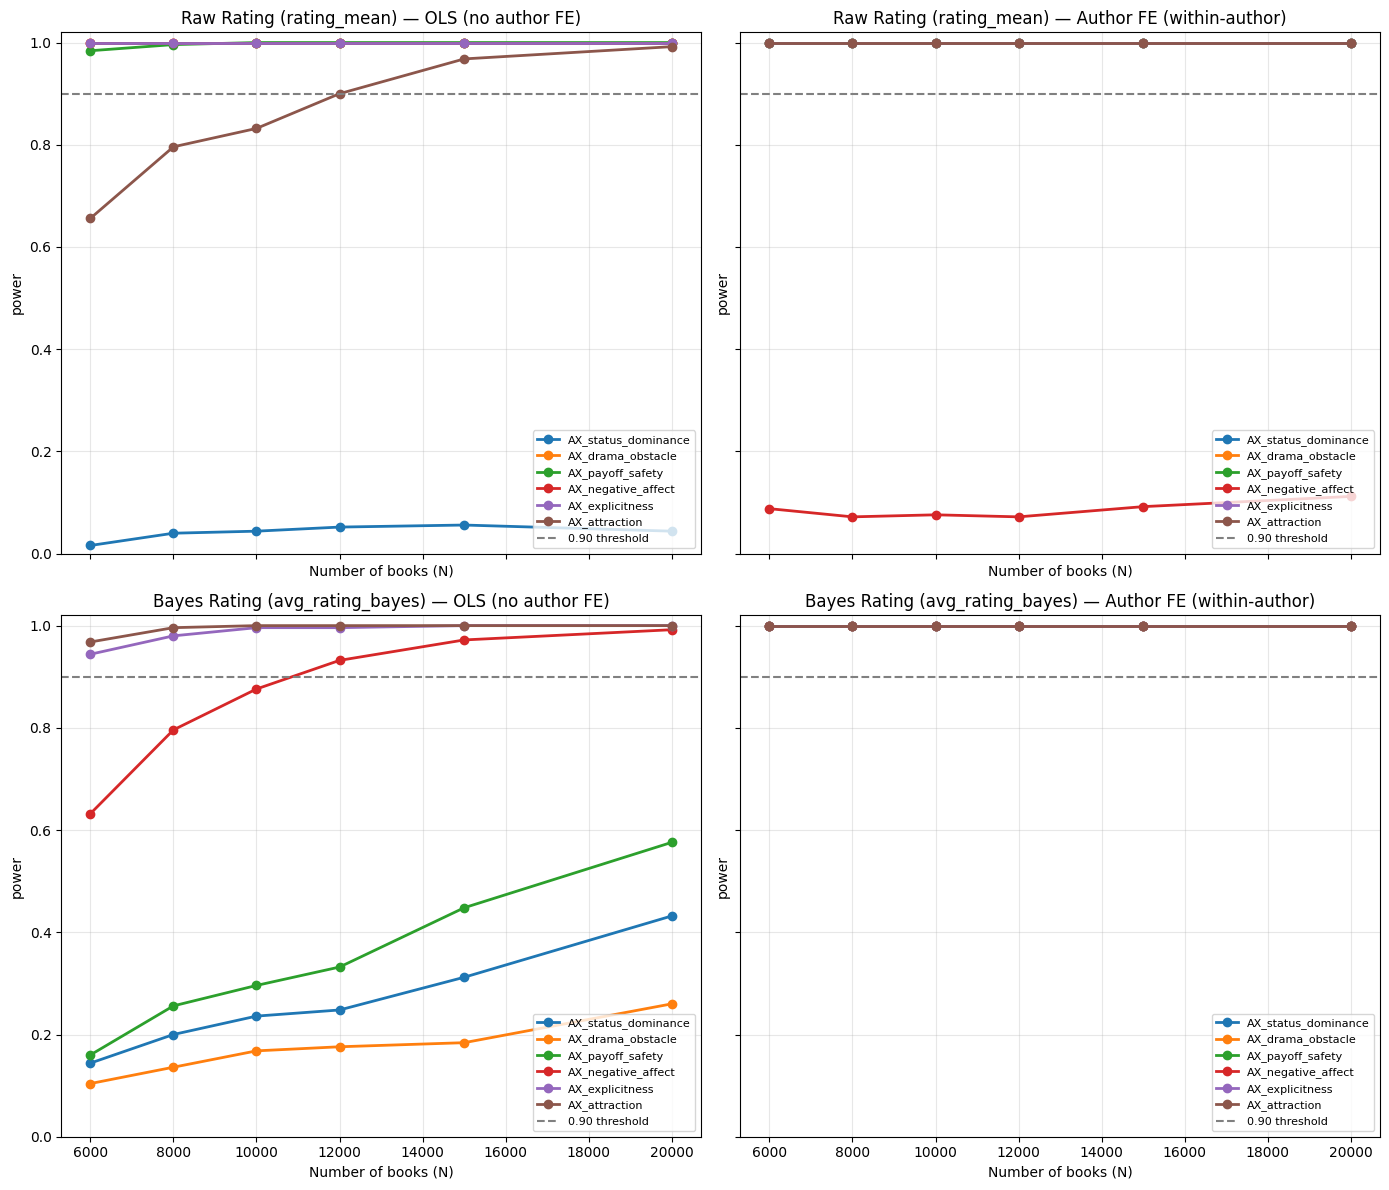


Plotting sign stability curves...


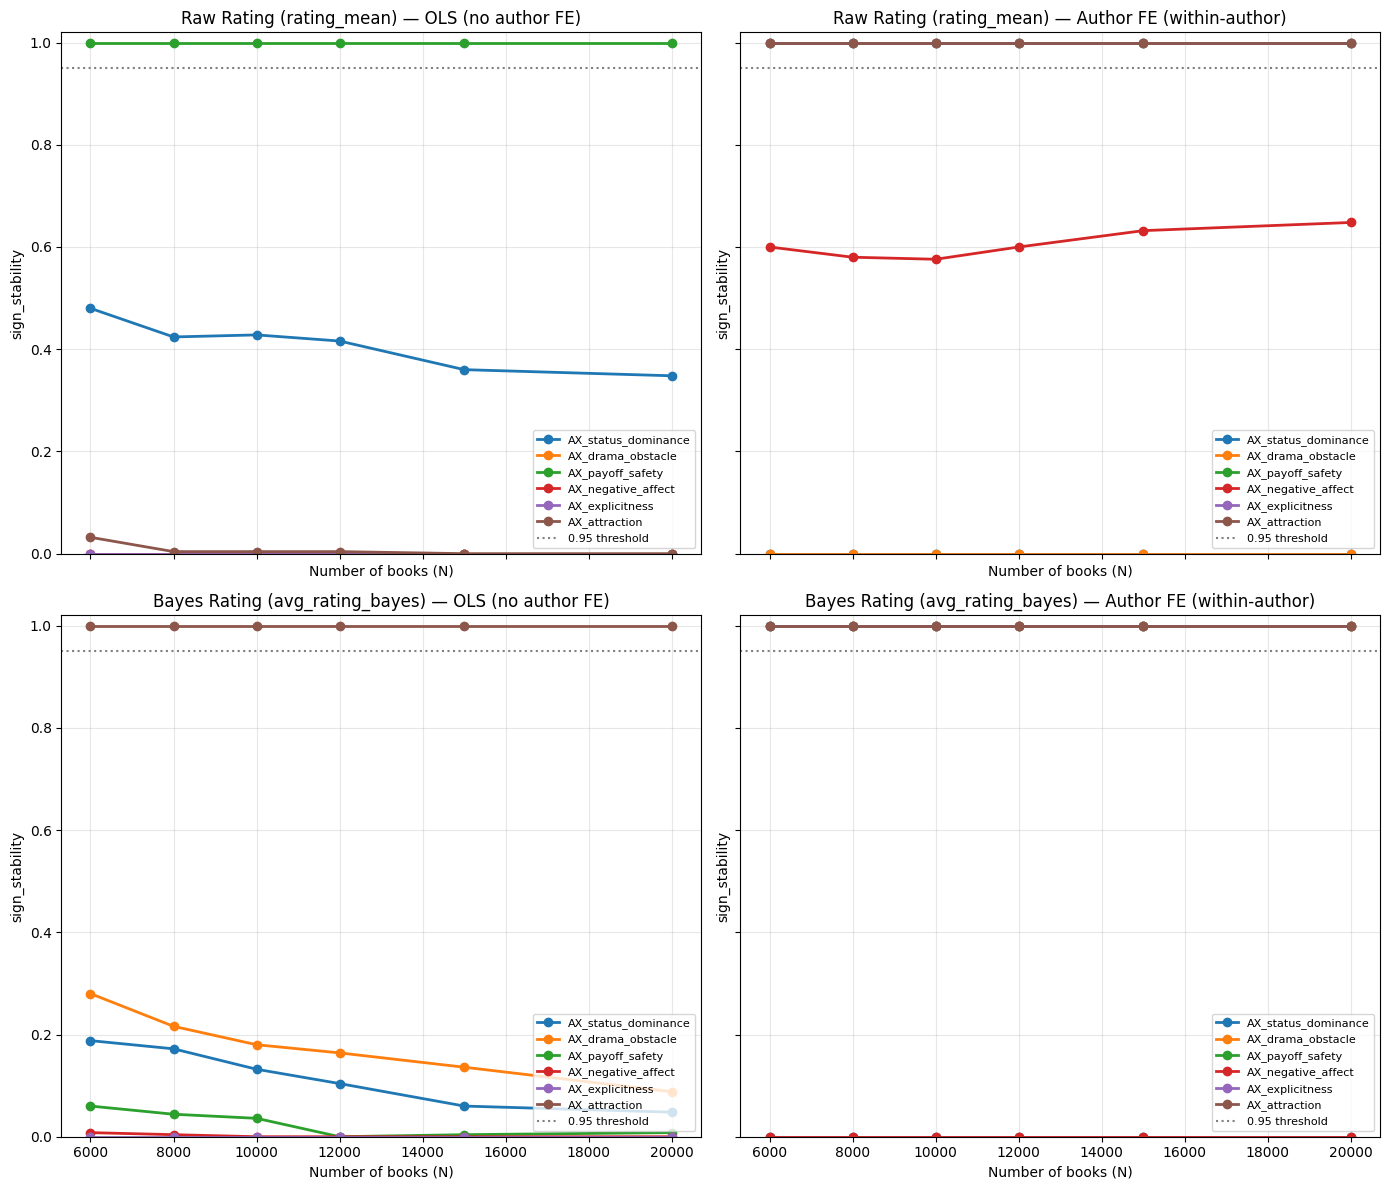

In [31]:
# ============================================================
# CELL 15 — Plot unified power curves (all axes, both outcomes, both models)
# ============================================================
def plot_power_curves(df_power: pd.DataFrame, metric: str = "power"):
    """
    metric: 'power' or 'sign_stability'
    Produces one figure with 2 rows (outcomes) and 2 columns (models).
    """
    models = df_power["model"].unique().tolist()
    outcomes = df_power["outcome"].unique().tolist()

    nrows = len(outcomes)
    ncols = len(models)

    fig, axes_grid = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 6 * nrows), sharex=True, sharey=True)
    if nrows == 1 and ncols == 1:
        axes_grid = np.array([[axes_grid]])
    elif nrows == 1:
        axes_grid = np.array([axes_grid])
    elif ncols == 1:
        axes_grid = np.array([[ax] for ax in axes_grid])

    for i, outcome in enumerate(outcomes):
        for j, model_name in enumerate(models):
            axp = axes_grid[i, j]
            sub = df_power[(df_power["outcome"] == outcome) & (df_power["model"] == model_name)]

            for axis_name in AXES:
                s = sub[sub["axis"] == axis_name].sort_values("N")
                if len(s) > 0:
                    axp.plot(s["N"], s[metric], marker="o", label=axis_name, linewidth=2)

            axp.set_title(f"{OUTCOMES.get(outcome, outcome)} — {model_name}")
            axp.set_xlabel("Number of books (N)")
            axp.set_ylabel(metric)

            if metric == "power":
                axp.axhline(0.90, linestyle="--", color="gray", label="0.90 threshold")
            else:
                axp.axhline(0.95, linestyle=":", color="gray", label="0.95 threshold")

            axp.set_ylim(0, 1.02)
            axp.legend(loc="lower right", fontsize=8)
            axp.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Plotting power curves...")
plot_power_curves(df_power, metric="power")

print("\nPlotting sign stability curves...")
plot_power_curves(df_power, metric="sign_stability")

In [32]:
# ============================================================
# CELL 16 — Print compact table: smallest N where power >= 0.90
# ============================================================
def min_n_for_threshold(df_power: pd.DataFrame, metric: str, thresh: float) -> pd.DataFrame:
    """Find smallest N achieving threshold for each axis/outcome/model combination."""
    out_rows = []
    for outcome in df_power["outcome"].unique():
        for model_name in df_power["model"].unique():
            for axis_name in AXES:
                s = df_power[
                    (df_power["outcome"] == outcome) &
                    (df_power["model"] == model_name) &
                    (df_power["axis"] == axis_name)
                ].sort_values("N")
                ok = s[s[metric] >= thresh]
                min_n = int(ok["N"].iloc[0]) if len(ok) > 0 else None
                out_rows.append({
                    "outcome": outcome,
                    "model": model_name,
                    "axis": axis_name,
                    f"min_N_{metric}_>={thresh}": min_n
                })
    return pd.DataFrame(out_rows)

print("\nSmallest N achieving 0.90 power:")
min_n_power = min_n_for_threshold(df_power, metric="power", thresh=0.90)
print(min_n_power.to_string(index=False))

print("\nSmallest N achieving 0.95 sign stability:")
min_n_sign = min_n_for_threshold(df_power, metric="sign_stability", thresh=0.95)
print(min_n_sign.to_string(index=False))


Smallest N achieving 0.90 power:
         outcome                     model                axis  min_N_power_>=0.9
     rating_mean        OLS (no author FE) AX_status_dominance                NaN
     rating_mean        OLS (no author FE)   AX_drama_obstacle             6000.0
     rating_mean        OLS (no author FE)    AX_payoff_safety             6000.0
     rating_mean        OLS (no author FE)  AX_negative_affect             6000.0
     rating_mean        OLS (no author FE)     AX_explicitness             6000.0
     rating_mean        OLS (no author FE)       AX_attraction            12000.0
     rating_mean Author FE (within-author) AX_status_dominance             6000.0
     rating_mean Author FE (within-author)   AX_drama_obstacle             6000.0
     rating_mean Author FE (within-author)    AX_payoff_safety             6000.0
     rating_mean Author FE (within-author)  AX_negative_affect                NaN
     rating_mean Author FE (within-author)     AX_explicitness  

In [33]:
# ============================================================
# CELL 1 — Setup & Path Resolution
# ============================================================
from __future__ import annotations

from pathlib import Path
import os
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def normalize_id(x) -> str:
    """Normalize book IDs (remove .0 suffix if present)."""
    s = str(x).strip()
    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]
    return s

# Find project root by walking up until we find both 'results' and 'data' directories
def find_project_root(start: Path) -> Path:
    """Walk up directory tree to find project root (contains both 'results' and 'data' directories)."""
    current = start.resolve()
    while current != current.parent:
        results_dir = current / "results"
        data_dir = current / "data"
        if results_dir.exists() and results_dir.is_dir() and data_dir.exists() and data_dir.is_dir():
            return current
        current = current.parent
    # Fallback: use environment variable
    env_root = os.environ.get("ROMANCE_ROOT", "")
    if env_root:
        return Path(env_root).expanduser().resolve()
    return Path.cwd().resolve()

# Try multiple strategies to find project root
PROJECT_ROOT = None

# Strategy 1: Use environment variable
env_root = os.environ.get("ROMANCE_ROOT", "")
if env_root and Path(env_root).expanduser().exists():
    PROJECT_ROOT = Path(env_root).expanduser().resolve()

# Strategy 2: Walk up from current working directory
if PROJECT_ROOT is None or not (PROJECT_ROOT / "results").exists():
    candidate = find_project_root(Path.cwd())
    if (candidate / "results").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate

# Final fallback: use known absolute path
if PROJECT_ROOT is None or not (PROJECT_ROOT / "results").exists():
    known_path = Path("/home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor")
    if known_path.exists() and (known_path / "results").exists() and (known_path / "data").exists():
        PROJECT_ROOT = known_path

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not determine PROJECT_ROOT. Please set ROMANCE_ROOT environment variable.")

PROJECT_ROOT = PROJECT_ROOT.resolve()
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR = PROJECT_ROOT / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("DATA_DIR:", DATA_DIR)

PROJECT_ROOT: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor
RESULTS_DIR: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results
DATA_DIR: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/data


In [34]:
# ============================================================
# CELL 17 — Save all results to stage08_power_analysis
# ============================================================
OUTPUT_DIR = RESULTS_DIR / "stage08_power_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Full power analysis results
power_results_path = OUTPUT_DIR / "power_analysis_results.csv"
df_power.to_csv(power_results_path, index=False)
print(f"Saved: {power_results_path}")

# 2. Minimum N for 0.90 power threshold
min_n_power_path = OUTPUT_DIR / "min_n_for_power_0.90.csv"
min_n_power.to_csv(min_n_power_path, index=False)
print(f"Saved: {min_n_power_path}")

# 3. Minimum N for 0.95 sign stability threshold
min_n_sign_path = OUTPUT_DIR / "min_n_for_sign_stability_0.95.csv"
min_n_sign.to_csv(min_n_sign_path, index=False)
print(f"Saved: {min_n_sign_path}")

# 4. Summary of simulation parameters
params_summary = pd.DataFrame([{
    "n_grid": str(N_GRID),
    "reps": REPS,
    "alpha": ALPHA,
    "outcomes": str(list(OUTCOMES.keys())),
    "axes": str(AXES),
    "n_books_pilot": len(df),
    "reach_control": REACH_COL,
    "author_col": AUTHOR_COL,
}])
params_path = OUTPUT_DIR / "simulation_parameters.csv"
params_summary.to_csv(params_path, index=False)
print(f"Saved: {params_path}")

print(f"\nAll results saved to: {OUTPUT_DIR}")

Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage08_power_analysis/power_analysis_results.csv
Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage08_power_analysis/min_n_for_power_0.90.csv
Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage08_power_analysis/min_n_for_sign_stability_0.95.csv
Saved: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage08_power_analysis/simulation_parameters.csv

All results saved to: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/stage08_power_analysis
